# BT-UNet
Self-supervised pretraining of the U-Net encoder using Barlow Twins, followed by supervised fine-tuning for segmentation across multiple label fractions.

**Pipeline:**
1. Pretrain the U-Net encoder with Barlow Twins (no labels needed)
2. Attach the decoder and fine-tune for segmentation at each label fraction (5%, 10%, 20%, 50%)

## Configuration

In [25]:
# ============================================================
# CONFIGURATION
# ============================================================

TRAIN_PATH   = "KDSB/train/"
TEST_PATH    = "KDSB/test/"
SAVE_DIR     = "saved_models"
SAVE_NP      = "saved_np"
DATASET_NAME = "KDSB"

IMG_HEIGHT   = 256
IMG_WIDTH    = 256
IMG_CHANNELS = 3

# Label fractions to sweep during fine-tuning
LABEL_FRACTIONS = [0.05, 0.10, 0.20, 0.50]
# LABEL_FRACTIONS = [0.50]


val_split  = 0.3
THRESHOLD  = 0.5

# Barlow Twins pretraining
PRETRAIN_EPOCHS    = 100
PRETRAIN_BATCH     = 8
PROJECT_DIM        = IMG_HEIGHT // 2
WEIGHT_DECAY       = 5e-4
PRETRAIN_FLG       = False   # False = load saved weights
PRETRAINED_WEIGHTS = "barlow_twins_unet.keras"

# Segmentation fine-tuning
FINETUNE_EPOCHS = 200
FINETUNE_BATCH  = 8
TRAIN_FLG       = True      # False = skip fine-tuning

# TEST_MODE: set True to smoke-test the full pipeline cheaply
TEST_MODE = False


## Imports

In [14]:
import os
import random
import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.io import imread, imshow
from skimage.morphology import label
from skimage.transform import resize

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import *
from tensorflow.keras.metrics import Accuracy, Precision, Recall, MeanIoU, MeanAbsoluteError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.python.ops import array_ops
from hausdorff import hausdorff_distance

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_NP,  exist_ok=True)
os.makedirs("logs/fit", exist_ok=True)


## Data Loading

In [15]:
x_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_train_path = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_train_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
x_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_X_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")
y_test_path  = os.path.join(SAVE_NP, f"{DATASET_NAME}_Y_test_{IMG_HEIGHT}x{IMG_WIDTH}.npy")

if all(os.path.exists(p) for p in [x_train_path, y_train_path, x_test_path, y_test_path]):
    print("Found cached arrays, loading...")
    X_train = np.load(x_train_path)
    Y_train = np.load(y_train_path)
    X_test  = np.load(x_test_path)
    Y_test  = np.load(y_test_path)
    print(f"Loaded — Train: {X_train.shape}, Test: {X_test.shape}")

else:
    print("No cached arrays found, loading and resizing from disk...")
    train_ids = next(os.walk(TRAIN_PATH + 'org/'))[2][:]
    test_ids  = next(os.walk(TEST_PATH  + 'org/'))[2][:]
    print(f"Train images: {len(train_ids)}, Test images: {len(test_ids)}")

    X_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_train = np.zeros((len(train_ids), IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)
    X_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), dtype=np.float32)
    Y_test  = np.zeros((len(test_ids),  IMG_HEIGHT, IMG_WIDTH, 1),            dtype=np.float32)

    for n, id_ in tqdm(enumerate(train_ids), total=len(train_ids)):
        img = imread(TRAIN_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_train[n] = img
        mask = imread(TRAIN_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_train[n][mask[:, :, 0] / 255 > 0.] = 1.

    for n, id_ in tqdm(enumerate(test_ids), total=len(test_ids)):
        img = imread(TEST_PATH + 'org/' + id_)[:, :, :IMG_CHANNELS]
        img = resize(img, (IMG_HEIGHT, IMG_WIDTH), mode='constant', preserve_range=True)
        X_test[n] = img
        mask = imread(TEST_PATH + 'gt/' + id_[:-4] + '_GT.png')
        mask = np.expand_dims(mask, axis=-1)
        mask = resize(mask, (IMG_HEIGHT, IMG_WIDTH, 1), mode='constant', preserve_range=True)
        Y_test[n][mask[:, :, 0] / 255 > 0.] = 1.

    np.save(x_train_path, X_train)
    np.save(y_train_path, Y_train)
    np.save(x_test_path,  X_test)
    np.save(y_test_path,  Y_test)
    print(f"Saved — Train: {X_train.shape}, Test: {X_test.shape}")


Found cached arrays, loading...
Loaded — Train: (2594, 256, 256, 3), Test: (1000, 256, 256, 3)


## U-Net Architecture
Identical to SimSiam-UNet and baseline UNet notebooks.

In [16]:
def double_conv_layer(x, filter_size, size, dropout, batch_norm=False):
    axis = 3
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    conv = SeparableConv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm:
        conv = BatchNormalization(axis=axis)(conv)
    conv = Activation('relu')(conv)
    if dropout > 0:
        conv = Dropout(dropout)(conv)
    shortcut = Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm:
        shortcut = BatchNormalization(axis=axis)(shortcut)
    return add([shortcut, conv])

def encoder(inputs):
    num_filters = [16, 32, 64, 128]
    skip_connections = []
    x = inputs
    for f in num_filters:
        a = double_conv_layer(x, 3, f, 0.1, True)
        skip_connections.append(a)
        x = MaxPooling2D(pool_size=(2, 2))(a)
    return x, skip_connections

def bottleneck(inputs):
    return double_conv_layer(inputs, 3, 256, 0.1, True)

def decoder(inputs, skip_connections):
    num_filters = [128, 64, 32, 16]
    skip_connections = skip_connections[::-1]
    x = inputs
    for i, f in enumerate(num_filters):
        x_up  = UpSampling2D(size=(2, 2), data_format="channels_last")(x)
        x_att = concatenate([x_up, skip_connections[i]], axis=-1)
        x     = double_conv_layer(x_att, 3, f, 0.1, True)
    return x

def output(inputs):
    x = Conv2D(1, kernel_size=(1, 1))(inputs)
    x = BatchNormalization()(x)
    x = Activation('sigmoid')(x)
    return x


## Barlow Twins Pretraining

**How Barlow Twins works:**
Two augmented views of the same image pass through the shared encoder.
The cross-correlation matrix between the two embeddings is pushed toward the identity — the diagonal toward 1 (invariance) and the off-diagonal toward 0 (redundancy reduction). No negative pairs or momentum encoder needed.

### Augmentation Pipeline

In [17]:
CROP_TO = IMG_HEIGHT
AUTO    = tf.data.AUTOTUNE
SEED    = 42

def random_resize_crop(image, scale=[0.75, 1.0], crop_size=128):
    image_shape = 96
    image = tf.image.resize(image, (image_shape, image_shape))
    size  = tf.random.uniform(shape=(1,), minval=scale[0]*image_shape,
                              maxval=scale[1]*image_shape, dtype=tf.float32)
    size  = tf.cast(size, tf.int32)[0]
    crop  = tf.image.random_crop(image, (size, size, 3))
    return tf.image.resize(crop, (crop_size, crop_size))

def flip_random_crop(image):
    image = tf.image.random_flip_left_right(image)
    return random_resize_crop(image, crop_size=CROP_TO)

def color_jitter(x, strength=0.5):
    x = tf.image.random_brightness(x, max_delta=0.8 * strength)
    x = tf.image.random_contrast(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_saturation(x, lower=1-0.8*strength, upper=1+0.8*strength)
    x = tf.image.random_hue(x, max_delta=0.2 * strength)
    return tf.clip_by_value(x, 0, 255)

def random_apply(func, x, p):
    return func(x) if tf.random.uniform([], 0, 1) < p else x

def custom_augment(image):
    image = tf.cast(image, tf.float32)
    image = flip_random_crop(image)
    image = random_apply(lambda x: tf.image.rot90(x), image, p=0.5)
    return image

ssl_ds_one = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds_two = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(1024, seed=SEED + 1)
    .map(custom_augment, num_parallel_calls=AUTO)
    .batch(PRETRAIN_BATCH)
    .prefetch(AUTO)
)
ssl_ds = tf.data.Dataset.zip((ssl_ds_one, ssl_ds_two))


### LR Schedule (WarmUp + Cosine Decay)
Identical to SimSiam-UNet notebook.

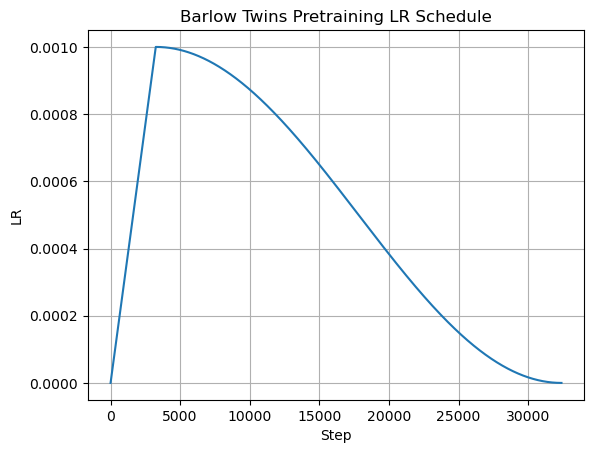

In [18]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base   = learning_rate_base
        self.total_steps          = total_steps
        self.warmup_learning_rate = warmup_learning_rate
        self.warmup_steps         = warmup_steps
        self.pi                   = tf.constant(np.pi)

    def __call__(self, step):
        if self.total_steps < self.warmup_steps:
            raise ValueError("total_steps must be >= warmup_steps")
        lr = (0.5 * self.learning_rate_base *
              (1 + tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps)
                          / float(self.total_steps - self.warmup_steps))))
        if self.warmup_steps > 0:
            slope       = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            lr          = tf.where(step < self.warmup_steps, warmup_rate, lr)
        return tf.where(step > self.total_steps, 0.0, lr)


STEPS_PER_EPOCH = len(X_train) // PRETRAIN_BATCH
TOTAL_STEPS     = STEPS_PER_EPOCH * PRETRAIN_EPOCHS
WARMUP_STEPS    = int(PRETRAIN_EPOCHS * 0.1) * STEPS_PER_EPOCH

lr_decayed_fn = WarmUpCosine(
    learning_rate_base=1e-3,
    total_steps=TOTAL_STEPS,
    warmup_learning_rate=0.0,
    warmup_steps=WARMUP_STEPS,
)

plt.plot(lr_decayed_fn(tf.range(TOTAL_STEPS, dtype=tf.float32)))
plt.title("Barlow Twins Pretraining LR Schedule")
plt.xlabel("Step")
plt.ylabel("LR")
plt.grid()
plt.show()


### Encoder + Projection Head

In [19]:
def projection_head(x, hidden_dim=128):
    for i in range(2):
        x = Dense(hidden_dim, kernel_regularizer=l2(WEIGHT_DECAY),
                  name=f"projection_layer_{i}")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
    x = Dense(hidden_dim, name="projection_output")(x)
    return x

def build_encoder(shape, hidden_dim=128):
    inputs = Input(shape)
    s = layers.Rescaling(1.0 / 255)(inputs)
    x, skip_connections = encoder(s)
    x = bottleneck(x)
    trunk_output       = GlobalAvgPool2D()(x)
    projection_outputs = projection_head(trunk_output, hidden_dim=hidden_dim)
    model = Model(inputs, projection_outputs, name="bt_encoder")
    return model

unet_enc = build_encoder((IMG_WIDTH, IMG_HEIGHT, IMG_CHANNELS), hidden_dim=PROJECT_DIM)
unet_enc.summary()


Model: "bt_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_10 │ (None, 256, 256,  │         91 │ rescaling_1[0][0] │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_11 │ (None, 256, 256,  │        416 │ activation_12[0]… │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │         64 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256, 256,  │          0 │ activation_13[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ add_5[0][0]       │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 128, 128,  │        688 │ max_pooling2d_4[… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 128, 128,  │      1,344 │ activation_14[0]

 Total params: 255,467 (997.92 KB)

 Trainable params: 251,979 (984.29 KB)

 Non-trainable params: 3,488 (13.62 KB)

### Barlow Twins Model

In [20]:
def off_diagonal(x):
    n = tf.shape(x)[0]
    flattened = tf.reshape(x, [-1])[:-1]
    off_diagonals = tf.reshape(flattened, (n-1, n+1))[:, 1:]
    return tf.reshape(off_diagonals, [-1])

def normalize_repr(z):
    return (z - tf.reduce_mean(z, axis=0)) / tf.math.reduce_std(z, axis=0)

def compute_loss(z_a, z_b, lambd):
    batch_size = tf.cast(tf.shape(z_a)[0], z_a.dtype)
    z_a_norm = normalize_repr(z_a)
    z_b_norm = normalize_repr(z_b)
    c = tf.matmul(z_a_norm, z_b_norm, transpose_a=True) / batch_size
    on_diag  = tf.reduce_sum(tf.pow(tf.linalg.diag_part(c) + (-1), 2))
    off_diag = tf.reduce_sum(tf.pow(off_diagonal(c), 2))
    return on_diag + (lambd * off_diag)

class BarlowTwins(tf.keras.Model):
    def __init__(self, encoder, lambd=5e-3):
        super().__init__()
        self.encoder      = encoder
        self.lambd        = lambd
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        ds_one, ds_two = data
        with tf.GradientTape() as tape:
            z_a = self.encoder(ds_one, training=True)
            z_b = self.encoder(ds_two, training=True)
            loss = compute_loss(z_a, z_b, self.lambd)
        gradients = tape.gradient(loss, self.encoder.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.encoder.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


### Run Pretraining

In [21]:
barlow_twins = BarlowTwins(unet_enc)
barlow_twins.compile(optimizer=SGD(learning_rate=lr_decayed_fn, momentum=0.9))
PRETRAIN_FLG = False  # Set to False to skip pretraining and load saved weights
if PRETRAIN_FLG:
    print("Pretraining Barlow Twins encoder...")
    pretrain_history = barlow_twins.fit(ssl_ds, epochs=PRETRAIN_EPOCHS)
    barlow_twins.encoder.save(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))
    plt.plot(pretrain_history.history["loss"])
    plt.title("Barlow Twins Pretraining Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()
else:
    print("Loading pretrained weights...")
    barlow_twins.encoder.load_weights(os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS))


Loading pretrained weights...


## Metrics

In [22]:
def iou_metric(y_true_in, y_pred_in):
    labels       = label(y_true_in > 0.5)
    y_pred       = label(y_pred_in > 0.5)
    true_objects = len(np.unique(labels))
    pred_objects = len(np.unique(y_pred))
    intersection = np.histogram2d(labels.flatten(), y_pred.flatten(),
                                  bins=(true_objects, pred_objects))[0]
    area_true    = np.expand_dims(np.histogram(labels, bins=true_objects)[0], -1)
    area_pred    = np.expand_dims(np.histogram(y_pred, bins=pred_objects)[0],  0)
    union        = area_true + area_pred - intersection
    intersection = intersection[1:, 1:]
    union        = union[1:, 1:]
    union[union == 0] = 1e-9
    iou = intersection / union

    def precision_at(threshold, iou):
        matches = iou > threshold
        tp = np.sum(np.sum(matches, axis=1) == 1)
        fp = np.sum(np.sum(matches, axis=0) == 0)
        fn = np.sum(np.sum(matches, axis=1) == 0)
        return tp, fp, fn

    prec = []
    for t in np.arange(0.5, 1.0, 0.05):
        tp, fp, fn = precision_at(t, iou)
        p = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
        prec.append(p)
    return np.mean(prec)

def iou_metric_batch(y_true_in, y_pred_in):
    return sum(iou_metric(y_true_in[b], y_pred_in[b])
               for b in range(y_true_in.shape[0])) / y_true_in.shape[0]

def dice_coeff(y_true, y_pred):
    smooth       = 1.
    y_true_f     = K.flatten(y_true)
    y_pred_f     = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def haud_dist(y_true, y_pred):
    return hausdorff_distance(np.squeeze(y_true), np.squeeze(y_pred))

def haud_dist_batch(y_true, y_pred):
    if len(y_true.shape) == 2:
        return haud_dist(y_true, y_pred)
    return sum(haud_dist(y_true[b], y_pred[b]) for b in range(y_true.shape[0])) / y_true.shape[0]

def evalResult(gt, pred, num_class=2):
    gt   = np.squeeze(gt)
    pred = np.squeeze(pred)
    acc  = Accuracy();  acc.update_state(gt, pred);  r_acc = acc.result().numpy()
    pr   = Precision(); pr.update_state(gt, pred);   r_pr  = pr.result().numpy()
    rc   = Recall();    rc.update_state(gt, pred);   r_rc  = rc.result().numpy()
    mi   = MeanIoU(num_class); mi.update_state(gt, pred); r_mi = mi.result().numpy()
    dc   = sum(dice_coeff(gt[i], pred[i]).numpy() for i in range(gt.shape[0])) / gt.shape[0]
    hd   = haud_dist_batch(gt, pred)
    miou = iou_metric_batch(gt, pred)
    mae  = MeanAbsoluteError()
    r_mae = mae(gt, pred).numpy()
    print(f"  Acc={r_acc:.4f}  Prec={r_pr:.4f}  Rec={r_rc:.4f}  MeanIoU={r_mi:.4f}  "
          f"Dice={dc:.4f}  HD={hd:.4f}  MyIoU={miou:.4f}  MAE={r_mae:.4f}")
    return dict(Accuracy=r_acc, Precision=r_pr, Recall=r_rc,
                MeanIoU=r_mi, Dice=dc, HD=hd, MyIoU=miou, MAE=r_mae)


## Loss Functions

In [23]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coeff(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    return 0.4 * binary_crossentropy(y_true, y_pred) + 0.6 * dice_loss(y_true, y_pred)


## Fine-tuning Loop — All Label Fractions
Rebuilds the full segmentation model fresh for each fraction, loading pretrained encoder weights each time.

In [ ]:
fractions_to_run = [LABEL_FRACTIONS[0]] if TEST_MODE else LABEL_FRACTIONS
FT_EPOCHS = 1  if TEST_MODE else FINETUNE_EPOCHS
FT_BATCH  = 2  if TEST_MODE else FINETUNE_BATCH
TEST_CAP  = 10

all_results = []

for fraction in fractions_to_run:
    pct     = int(fraction * 100)
    keyname = f"BT-UNet_{pct}pct"
    print(f"\n{'='*60}")
    print(f"Fine-tuning: {keyname}  ({pct}% labelled data)")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    # ---- Slice labelled subset ----
    n_labelled = int(X_train.shape[0] * fraction)
    if TEST_MODE:
        n_labelled = min(n_labelled, TEST_CAP)
        print(f"[TEST_MODE] capped to {n_labelled} samples, {FT_EPOCHS} epoch")
    X_subset = X_train[:n_labelled]
    Y_subset = Y_train[:n_labelled]

    # ---- Rebuild backbone from pretrained encoder ----
    pretrained_enc = tf.keras.models.load_model(
        os.path.join(SAVE_DIR, PRETRAINED_WEIGHTS), compile=False
    )
    backbone = tf.keras.Model(
        pretrained_enc.input,
        pretrained_enc.layers[-9].output,
        name="backbone"
    )
    backbone.trainable = True

    new_skip_connections = [
        backbone.get_layer(index=11).output,
        backbone.get_layer(index=22).output,
        backbone.get_layer(index=33).output,
        backbone.get_layer(index=44).output,
    ]

    x       = decoder(backbone.output, new_skip_connections)
    outputs = output(x)
    model   = Model(backbone.input, outputs, name=keyname)

    # ---- Callbacks ----
    cur_date = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = [
        ModelCheckpoint(
            os.path.join(SAVE_DIR, f"model_{keyname}.keras"),
            monitor='val_loss', verbose=1, save_best_only=True
        ),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10),
        EarlyStopping(monitor='val_loss', verbose=1, patience=20),
        CSVLogger(f"logs/{keyname}_{cur_date}.log"),
        TensorBoard(log_dir=f"logs/fit/{keyname}_{cur_date}", histogram_freq=0),
    ]

    # ---- Compile + Train ----
    model.compile(
        loss=bce_dice_loss,
        optimizer=Adam(),
        metrics=['accuracy', Precision(), MeanIoU(num_classes=2), Recall(),
                 dice_coeff, MeanAbsoluteError()]
    )

    if TRAIN_FLG:
        history = model.fit(
            X_subset, Y_subset,
            validation_split=val_split,
            batch_size=FT_BATCH,
            epochs=FT_EPOCHS,
            callbacks=callbacks
        )
        plt.plot(history.history['loss'],     label='train')
        plt.plot(history.history['val_loss'], label='val')
        plt.title(f"{keyname} — Loss")
        plt.legend()
        plt.grid()
        plt.show()
    else:
        print("Loading saved weights...")
        model.load_weights(os.path.join(SAVE_DIR, f"model_{keyname}.keras"))

    # ---- Evaluate ----
    split_idx  = int(X_subset.shape[0] * (1 - val_split))
    X_tr_split = X_subset[:split_idx]
    Y_tr_split = Y_subset[:split_idx]
    X_val      = X_subset[split_idx:]
    Y_val      = Y_subset[split_idx:]

    preds_train = (model.predict(X_tr_split, verbose=1) > THRESHOLD).astype(np.float32)
    preds_full  = (model.predict(X_train,    verbose=1) > THRESHOLD).astype(np.float32)
    preds_val   = (model.predict(X_val,      verbose=1) > THRESHOLD).astype(np.float32)
    preds_test  = (model.predict(X_test,     verbose=1) > THRESHOLD).astype(np.float32)

    print("\nTRAIN")
    train_m = evalResult(Y_tr_split.astype(np.float32), preds_train)
    print("\nFULL DATASET")
    full_m  = evalResult(Y_train.astype(np.float32),    preds_full)
    print("\nVALIDATION")
    val_m   = evalResult(Y_val.astype(np.float32),      preds_val)
    print("\nTEST")
    test_m  = evalResult(Y_test.astype(np.float32),     preds_test)

    row = {"Model": keyname, "Label Fraction (%)": pct}
    for split_name, metrics in [("Train", train_m), ("Full", full_m),
                                  ("Val", val_m), ("Test", test_m)]:
        for k, v in metrics.items():
            row[f"{split_name} {k}"] = v
    all_results.append(row)

print("\nAll label fractions complete.")



Fine-tuning: BT-UNet_50pct  (50% labelled data)

Epoch 1/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.8016 - dice_coeff: 0.4975 - loss: 0.5093 - mean_absolute_error: 0.3746 - mean_io_u: 0.3618 - precision: 0.6119 - recall: 0.7789
Epoch 1: val_loss improved from None to 0.58405, saving model to saved_models\model_BT-UNet_50pct.keras

Epoch 1: finished saving model to saved_models\model_BT-UNet_50pct.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 63s 469ms/step - accuracy: 0.8330 - dice_coeff: 0.5258 - loss: 0.4779 - mean_absolute_error: 0.3537 - mean_io_u: 0.3595 - precision: 0.6644 - recall: 0.8202 - val_accuracy: 0.8222 - val_dice_coeff: 0.3646 - val_loss: 0.5841 - val_mean_absolute_error: 0.3853 - val_mean_io_u: 0.3767 - val_precision: 0.7790 - val_recall: 0.3892 - learning_rate: 0.0010
Epoch 2/200
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8782 - dice_coeff: 0.5564 - loss: 0.4361 - mean_absolute_error: 0.3193 - mean_io_u: 0.3622 - precision: 0.7411 - recall: 0.857

## Results Table

In [ ]:
results_df = pd.DataFrame(all_results)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

print("\n================ FINAL RESULTS ================\n")
display(results_df)

results_df.to_csv(os.path.join(SAVE_DIR, "bt_unet_results.csv"), index=False)
print("Saved to bt_unet_results.csv")


## Qualitative Visualisation

In [ ]:
# Reload the best model (50% fraction) for visualisation
best_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "model_BT-UNet_50pct.keras"), compile=False
)
preds_test_vis = (best_model.predict(X_test, verbose=0) > THRESHOLD).astype(np.float32)

sample_idx = [0, 1, 2]
fig, axes  = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))
for row, ix in enumerate(sample_idx):
    axes[row, 0].imshow(X_test[ix].astype('uint8'));              axes[row, 0].set_title('Image');     axes[row, 0].axis('off')
    axes[row, 1].imshow(np.squeeze(Y_test[ix]), cmap='gray');     axes[row, 1].set_title('GT Mask');   axes[row, 1].axis('off')
    axes[row, 2].imshow(np.squeeze(preds_test_vis[ix]), cmap='gray'); axes[row, 2].set_title('Predicted'); axes[row, 2].axis('off')
plt.tight_layout()
plt.show()
